<img src="Institute-of-Chartered-Foresters-edited.png" width="200">


# Supplementary 1. Data preparation, environmental variables and feature selection

**Author:** Jorge Lizarazo  

**journal:** *Forestry: An International Journal of Forest Research*

This supplementary notebook documents the raw forest-inventory import, cleaning
of missing values and invalid placeholders, exploratory principal component
analysis (PCA) for an initial overview of environmental variation, LightGBM
feature importance as a first ranking of climatic and edaphic predictors, and a
multicollinearity filter used to obtain the reduced predictor set that feeds
into Supplementary 2–6.

**Inputs.** `data/data_final_forestry_2.csv` (raw forest-inventory table with
environmental attributes).

**Outputs.** `data/df_important.csv` (the final variable set).

**Note.** This notebook is preserved as it was used during the analysis. The
current modelling pipeline is Supplementary 5–6 (grid-based XGBoost with
conifer-associated ecological filters); the variable selection here is the
upstream step that produced the environmental predictors used there.

<!-- supp-intro:v2 -->
## Notebook scope

This supplementary documents the predictor-screening pipeline used to build the
reduced environmental variable set that feeds Supplementary 2–6. It contains:

1. Import and quality control of the raw forest-inventory table.
2. An exploratory PCA of the standardised numeric predictors.
3. A LightGBM-based feature-importance ranking.
4. A multicollinearity filter applied to the ranked predictors.
5. Export of the final dataset to `data/df_important.csv`.

The companion CSV `outputs/summary/stats/s1_predictor_selection_summary.csv`
records the predictors retained or dropped at each step. The note at the end
of the notebook (S1 statistical note) clarifies that this stage is descriptive
and algorithmic; formal inference begins in Supplementary 3 (GAM) and continues
in Supplementary 5–6 (XGBoost grid models).

Sole author: Jorge Lizarazo. Target journal: *Forestry: An International
Journal of Forest Research*. The `forest` predictor is **excluded** from the
exported variable set because its future dynamics cannot be projected
reliably.


## Data import and preparation

The script loads the CSV dataset (resultados_bioclimaticos_2.csv) containing climatic, edaphic, and occurrence data for both species. Columns are read with explicit data types to ensure numeric consistency. Records corresponding to _Acer saccharinum_ (“EA”) are excluded, and duplicates based on geographic coordinates and species identity are removed to avoid spatial redundancy.

In [1]:
# matplotlib-inline-addon
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')


In [2]:
#testing



dtype_spec = {
    'latitude': 'float64',
    'longitude': 'float64',
    'geocode': 'object',
    'essence': 'object',
    'RES_CO_REG': 'object'
}

csv_file_path = 'data/resultados_bioclimaticos_2.csv'

In [3]:
import matplotlib.pyplot as plt

In [4]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv(csv_file_path, dtype=dtype_spec)
dfff = df[df['elev'] >= 0].copy()

In [6]:
dfff

,latitude,longitude,geocode,densite,essence,RES_CO_REG,bio10,bio11,bio12,bio13,...,bio7,bio8,bio9,clay,elev,forest,ph,sand,wetland_mean_500km,wetland_cover500km
0,48.396359,-68.500026,"-1,95+488589,87",85.0,EO,1.0,15.244105,-12.083439,1037.675,143.950,...,41.710550,3.165525,-0.290782,26.0,200,90,4.5500,37.0,0.0,0.0
1,47.996187,-68.500146,"-10,88+444262,80",95.0,ES,1.0,15.910181,-12.535620,1024.825,147.400,...,43.808228,6.911122,-3.073537,11.0,364,94,4.2000,56.0,0.0,0.0
2,47.849696,-68.513409,"-1000,27+428030,35",75.0,ES,1.0,15.910181,-12.535620,1024.825,147.400,...,43.808228,6.911122,-3.073537,11.0,392,100,4.2000,56.0,0.0,0.0
3,48.378256,-68.635551,"-10000,44+486594,57",75.0,EO,1.0,15.244105,-12.083439,1037.675,143.950,...,41.710550,3.165525,-0.290782,26.0,150,99,4.5500,37.0,0.0,0.0
4,47.003192,-69.817548,"-100004,79+335083,92",75.0,EO,12.0,15.960852,-11.905567,1006.475,150.150,...,42.529510,7.131128,0.016549,24.0,351,100,3.5167,45.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1729498,48.619350,-67.341882,"85006,15+513968,98",85.0,ES,1.0,14.631895,-12.475888,1016.175,148.450,...,42.201370,7.313736,-3.404632,11.0,197,37,4.2000,56.0,0.0,0.0
1729499,48.621634,-67.341360,"85040,33+514222,47",85.0,EO,1.0,14.631895,-12.475888,1016.175,148.450,...,42.201370,7.313736,-3.404632,11.0,241,83,4.2000,56.0,0.0,0.0
1729500,48.621634,-67.341360,"85040,33+514222,47",85.0,ES,1.0,14.631895,-12.475888,1016.175,148.450,...,42.201370,7.313736,-3.404632,11.0,241,83,4.2000,56.0,0.0,0.0
1729501,47.971029,-67.199845,"96735,11+442354,05",85.0,EO,11.0,14.640681,-12.711493,992.825,151.975,...,43.397110,6.632061,-1.480228,25.0,199,78,4.4400,31.0,0.0,0.0


In [7]:

#os.environ['OPENBLAS_NUM_THREADS'] = '1'
#os.environ['MKL_NUM_THREADS'] = '1'
#os.environ['NUMEXPR_NUM_THREADS'] = '1'
#os.environ['OMP_NUM_THREADS'] = '1'

In [8]:
#import os
#import requests
#import geopandas as gpd
#import zipfile
#import xarray as xr
#from shapely.geometry import mapping
#import glob


In [9]:
#dfff = dfff.drop(['geocode'], axis=1) #
dfff = dfff[dfff['essence'] != 'EA']

In [10]:
dfff.head(3)

,latitude,longitude,geocode,densite,essence,RES_CO_REG,bio10,bio11,bio12,bio13,...,bio7,bio8,bio9,clay,elev,forest,ph,sand,wetland_mean_500km,wetland_cover500km
0,48.396359,-68.500026,"-1,95+488589,87",85.0,EO,1.0,15.244105,-12.083439,1037.675,143.95,...,41.710550,3.165525,-0.290782,26.0,200,90,4.55,37.0,0.0,0.0
1,47.996187,-68.500146,"-10,88+444262,80",95.0,ES,1.0,15.910181,-12.535620,1024.825,147.40,...,43.808228,6.911122,-3.073537,11.0,364,94,4.20,56.0,0.0,0.0
2,47.849696,-68.513409,"-1000,27+428030,35",75.0,ES,1.0,15.910181,-12.535620,1024.825,147.40,...,43.808228,6.911122,-3.073537,11.0,392,100,4.20,56.0,0.0,0.0


In [11]:
catego = dfff['essence'].unique()
print(catego)

['EO' 'ES']


In [12]:
print(dfff.shape)       # tamaño original

(1717347, 48)


In [13]:
dfff = dfff.drop_duplicates(subset=['latitude', 'longitude', 'essence'])

print(dfff.shape) # tamaño después de eliminar duplicados

(1656033, 48)


In [14]:
color_mapping = {
    'ES':1, 'EO':2
    #'EI':3,
   # 'EA':3
}
colors = ['#bc5090', '#ff6361'
          #'#58508d',
         # '#888f7d'
         ]  # Rojo, Verde, Azul, etc.


In [15]:
# Mapeo de nombres completos
full_names = {
    #'EA': 'Acer saccharinum (Érable argenté o Arce plateado)',
    'EO': 'Acer rubrum (Érable rouge o Arce rojo)',
    'ES': 'Acer saccharum (Érable à sucre o Arce de azúcar)'
}

In [16]:
num_nan = dfff.isna().sum()
num_nan

latitude              0
longitude             0
geocode               0
densite               0
essence               0
RES_CO_REG            0
bio10                 0
bio11                 0
bio12                 0
bio13                 0
bio14                 0
bio15                 0
bio16                 0
bio17                 0
bio18                 0
bio19                 0
bio1                  0
bio20                 0
bio21                 0
bio22                 0
bio23                 0
bio24                 0
bio25                 0
bio26                 0
bio27                 0
bio28                 0
bio29                 0
bio2                  0
bio30                 0
bio31                 0
bio32                 0
bio33                 0
bio34                 0
bio35                 0
bio3                  0
bio4                  0
bio5                  0
bio6                  0
bio7                  0
bio8                  0
bio9                  0
clay            

In [17]:
num_neg_999 = (dfff == -999).sum()
num_neg_999

latitude              0
longitude             0
geocode               0
densite               0
essence               0
RES_CO_REG            0
bio10                 0
bio11                 0
bio12                 0
bio13                 0
bio14                 0
bio15                 0
bio16                 0
bio17                 0
bio18                 0
bio19                 0
bio1                  0
bio20                 0
bio21                 0
bio22                 0
bio23                 0
bio24                 0
bio25                 0
bio26                 0
bio27                 0
bio28                 0
bio29                 0
bio2                  0
bio30                 0
bio31                 0
bio32                 0
bio33                 0
bio34                 0
bio35                 0
bio3                  0
bio4                  0
bio5                  0
bio6                  0
bio7                  0
bio8                  0
bio9                  0
clay            

Missing values and invalid placeholders (e.g. –999) are detected. A brief summary of the dataset dimensions and categories of the variable essence is printed to confirm data integrity before analysis.

In [18]:
numeric_cols = dfff.select_dtypes(include=[np.number])


is_neg_999 = numeric_cols == -999
columns_with_neg_999 = is_neg_999.any()
print("Columnas con valores igual a -999:")
print(columns_with_neg_999[columns_with_neg_999].index.tolist())

Columnas con valores igual a -999:
[]


In [19]:
#dfff = dfff.drop('unified', axis=1)

In [20]:

print(dfff.columns)

Index(['latitude', 'longitude', 'geocode', 'densite', 'essence', 'RES_CO_REG',
       'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17',
       'bio18', 'bio19', 'bio1', 'bio20', 'bio21', 'bio22', 'bio23', 'bio24',
       'bio25', 'bio26', 'bio27', 'bio28', 'bio29', 'bio2', 'bio30', 'bio31',
       'bio32', 'bio33', 'bio34', 'bio35', 'bio3', 'bio4', 'bio5', 'bio6',
       'bio7', 'bio8', 'bio9', 'clay', 'elev', 'forest', 'ph', 'sand',
       'wetland_mean_500km', 'wetland_cover500km'],
      dtype='object')


In [21]:
import seaborn as sns



In [22]:
#pip install PCA StandardScaler

## Exploratory Principal Component Analysis (PCA)

All numeric predictors are standardized and submitted to PCA to visualise major environmental gradients and potential collinearity among variables.
The script plots the explained variance of each component and produces biplots (PCA0–PCA1–PCA2) where arrows represent the loadings of original variables, showing how climatic and edaphic factors structure the data space for both maple species.

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [24]:
numeric_columns = dfff.select_dtypes(include='number').columns.tolist()
dfff_numeric = dfff[numeric_columns]

In [25]:
dfff_numeric = dfff.drop(columns=['densite']).select_dtypes(include='number')

In [26]:
scaler = StandardScaler()
dfff_scaled = scaler.fit_transform(dfff_numeric)

In [27]:
import numpy as np

In [28]:
pca = PCA()
pca_components = pca.fit_transform(dfff_scaled)

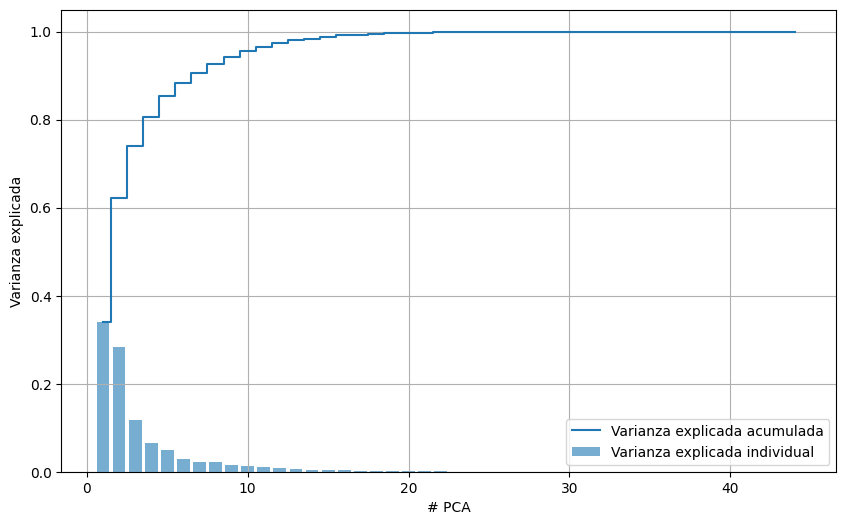

In [29]:
explained_variance = pca.explained_variance_ratio_

cumulative_explained_variance = np.cumsum(explained_variance)
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.6, label='Varianza explicada individual')
plt.step(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, where='mid', label='Varianza explicada acumulada')
plt.xlabel('# PCA')
plt.ylabel('Varianza explicada')
plt.title('')
plt.legend(loc='best')
plt.grid(True)
plt.show()

Three principal components explain 77% aprox...

In [30]:
np.sum(pca.explained_variance_ratio_[0:3])

np.float64(0.7397784239469317)

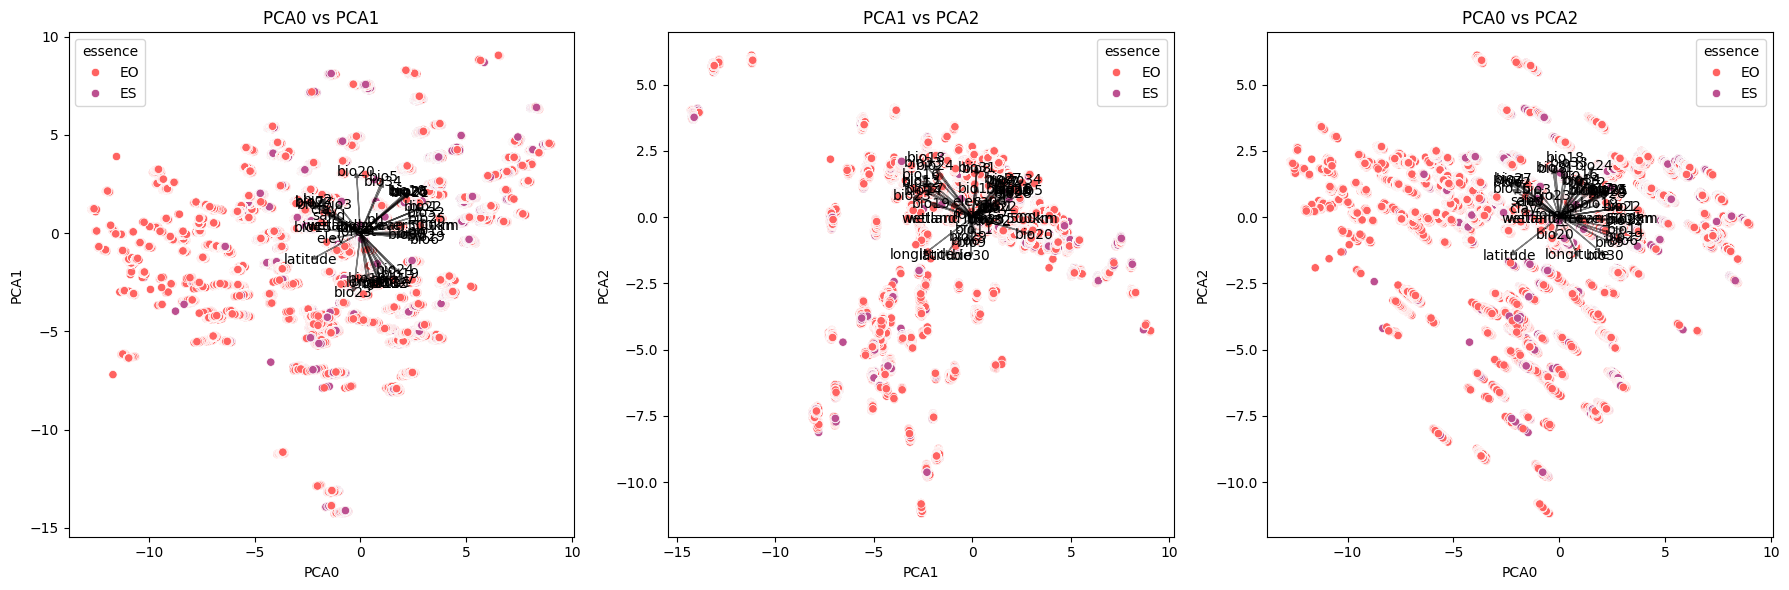

In [31]:
# Crear un DataFrame para los tres primeros componentes principales
pca_df = pd.DataFrame(data=pca_components[:, 0:3], columns=['PCA0', 'PCA1', 'PCA2'])

# Añadir la columna 'essence' para la visualización
pca_df['essence'] = dfff['essence'].values

# Obtener los loadings (coeficientes) de las variables originales en los componentes principales
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Escalar los loadings para mejorar la visualización
scaling_factor = 3
loadings_scaled = loadings * scaling_factor

# Definir los gráficos biplot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# PCA0 vs PCA1
sns.scatterplot(x='PCA0', y='PCA1', hue='essence', palette={key: colors[color_mapping[key] - 1] for key in color_mapping}, data=pca_df, ax=axes[0])
axes[0].set_title('PCA0 vs PCA1')
axes[0].set_xlabel('PCA0')
axes[0].set_ylabel('PCA1')

# Añadir flechas de loadings
for i in range(loadings.shape[0]):
    axes[0].arrow(0, 0, loadings_scaled[i, 0], loadings_scaled[i, 1], color='black', alpha=0.5, head_width=0.2, head_length=0.2)
    axes[0].text(loadings_scaled[i, 0]*1.1, loadings_scaled[i, 1]*1.1, dfff_numeric.columns[i], color='black', ha='center', va='center')

# PCA1 vs PCA2
sns.scatterplot(x='PCA1', y='PCA2', hue='essence', palette={key: colors[color_mapping[key] - 1] for key in color_mapping}, data=pca_df, ax=axes[1])
axes[1].set_title('PCA1 vs PCA2')
axes[1].set_xlabel('PCA1')
axes[1].set_ylabel('PCA2')

# Añadir flechas de loadings
for i in range(loadings.shape[0]):
    axes[1].arrow(0, 0, loadings_scaled[i, 1], loadings_scaled[i, 2], color='black', alpha=0.5, head_width=0.2, head_length=0.2)
    axes[1].text(loadings_scaled[i, 1]*1.1, loadings_scaled[i, 2]*1.1, dfff_numeric.columns[i], color='black', ha='center', va='center')

# PCA0 vs PCA2
sns.scatterplot(x='PCA0', y='PCA2', hue='essence', palette={key: colors[color_mapping[key] - 1] for key in color_mapping}, data=pca_df, ax=axes[2])
axes[2].set_title('PCA0 vs PCA2')
axes[2].set_xlabel('PCA0')
axes[2].set_ylabel('PCA2')

# Añadir flechas de loadings
for i in range(loadings.shape[0]):
    axes[2].arrow(0, 0, loadings_scaled[i, 0], loadings_scaled[i, 2], color='black', alpha=0.5, head_width=0.2, head_length=0.2)
    axes[2].text(loadings_scaled[i, 0]*1.1, loadings_scaled[i, 2]*1.1, dfff_numeric.columns[i], color='black', ha='center', va='center')

# Ajustar el espacio entre los subgráficos
plt.tight_layout()
plt.show()

### Variable contribution ranking

Loadings are extracted and summed to quantify the total contribution of each variable to the first three principal components. This step highlights which predictors drive the greatest multivariate differentiation.

In [32]:
# Obtenemos las cargas (loadings) de las variables en los primeros tres componentes principales
loadings = pca.components_[:3]
loadings_df = pd.DataFrame(loadings.T, index=dfff_numeric.columns, columns=[f'PC{i+1}' for i in range(3)])
loadings_df['Total_Contribution'] = loadings_df.abs().sum(axis=1)
sorted_loadings = loadings_df.sort_values(by='Total_Contribution', ascending=False)
print(sorted_loadings.head(40))

                PC1       PC2       PC3  Total_Contribution
bio24      0.127714 -0.161730  0.255137            0.544581
bio33      0.037191 -0.215066  0.271744            0.524001
bio18      0.023850 -0.200300  0.296624            0.520774
bio16      0.073999 -0.224353  0.211067            0.509420
bio12      0.105639 -0.222253  0.171117            0.499010
bio7      -0.189076  0.135382  0.174022            0.498480
bio27     -0.170996  0.133265  0.192828            0.497090
bio34      0.085771  0.222857  0.186604            0.495231
bio21      0.185257  0.175132  0.134100            0.494488
bio26      0.181648  0.178053  0.134535            0.494236
latitude  -0.183005 -0.116775 -0.193853            0.493634
bio10      0.174067  0.182969  0.133400            0.490436
bio13      0.081959 -0.222947  0.183194            0.488100
bio35      0.183970  0.177582  0.126409            0.487961
bio4      -0.178930  0.121976  0.186629            0.487535
longitude  0.068269 -0.217143 -0.191989 

In [33]:
#selected_variables = sorted_loadings[sorted_loadings['Total_Contribution'] > 0.45].index.tolist()
#!pip install lightgbm
# Crear un nuevo DataFrame con las variables seleccionadas
#dfff_selected = dfff_numeric[selected_variables]

## Feature importance using LightGBM

A Light Gradient Boosting Machine (LightGBM) classifier is trained to predict species identity (essence) from environmental variables. The resulting feature‐importance scores quantify the relative predictive power of each variable.

In [34]:
#from sklearn.model_selection import GridSearchCV
import lightgbm as lgb
from sklearn.model_selection import train_test_split

In [35]:
X = dfff.drop(columns=[ 'essence', 'densite', 'RES_CO_REG', 'longitude',
                        'latitude', 'geocode'])  # Excluyendo 'geocode', 'essence' y 'densite'
Y = dfff['essence']

The resulting feature‐importance scores quantify the relative predictive power of each variable and reveal which climatic and edaphic gradients best discriminate between _Acer saccharum_ and _A. rubrum_. This step is crucial for assessing whether the two species occupy distinct environmental niches—thus supporting the use of separate clustering analyses—or whether their occurrences can be treated as a continuum within shared ecological gradients.
In other words, LightGBM provides an empirical basis to decide whether niche differentiation or niche overlap predominates across Quebec’s maple populations.

In [36]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Crear y entrenar el modelo LightGBM
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train, Y_train)

# Importancia de las características
importances = lgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

[LightGBM] [Info] Number of positive: 395847, number of negative: 763376
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.060591 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6876
[LightGBM] [Info] Number of data points in the train set: 1159223, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.341476 -> initscore=-0.656723
[LightGBM] [Info] Start training from score -0.656723


               Feature  Importance
36                elev         619
37              forest         239
35                clay         157
39                sand         153
38                  ph         149
28                bio3         120
0                bio10          96
1                bio11          95
5                bio15          91
18               bio27          87
26               bio34          75
32                bio7          70
3                bio13          69
4                bio14          68
2                bio12          67
23               bio31          63
30                bio5          61
7                bio17          60
22               bio30          55
10                bio1          51
34                bio9          49
33                bio8          45
9                bio19          43
15               bio24          38
11               bio20          34
40  wetland_mean_500km          34
8                bio18          32
21                bi

In [37]:
from sklearn.preprocessing import LabelEncoder

In [38]:
# Convertir Y a valores numéricos si es necesario
label_encoder = LabelEncoder()
Y_encoded = label_encoder.fit_transform(Y)

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(X, Y_encoded, test_size=0.3, random_state=42)

# Crear y entrenar el modelo LightGBM
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train, Y_train)

# Importancia de las características
importances = lgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)


[LightGBM] [Info] Number of positive: 395847, number of negative: 763376
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.056114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6876
[LightGBM] [Info] Number of data points in the train set: 1159223, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.341476 -> initscore=-0.656723
[LightGBM] [Info] Start training from score -0.656723


               Feature  Importance
36                elev         619
37              forest         239
35                clay         157
39                sand         153
38                  ph         149
28                bio3         120
0                bio10          96
1                bio11          95
5                bio15          91
18               bio27          87
26               bio34          75
32                bio7          70
3                bio13          69
4                bio14          68
2                bio12          67
23               bio31          63
30                bio5          61
7                bio17          60
22               bio30          55
10                bio1          51
34                bio9          49
33                bio8          45
9                bio19          43
15               bio24          38
11               bio20          34
40  wetland_mean_500km          34
8                bio18          32
21                bi

In [39]:
imp_df = feature_importance_df.copy()

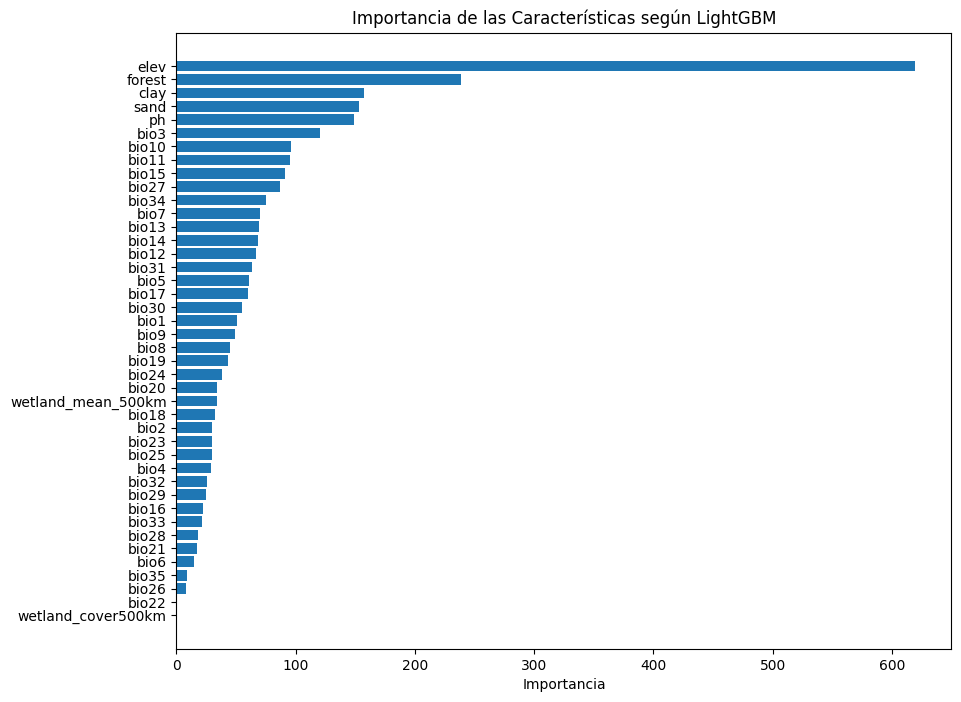

In [40]:
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importancia')
plt.title('Importancia de las Características según LightGBM')
plt.show()

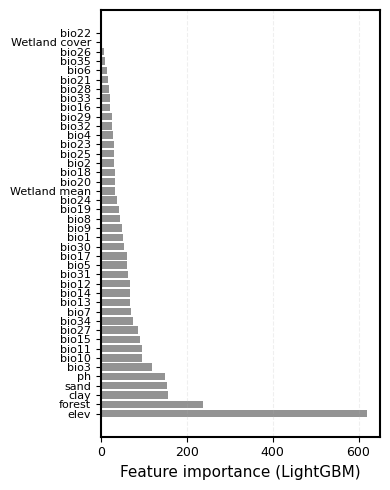

In [41]:

feature_importance_df_plot = feature_importance_df.copy()

# Rename wetland variables for publication clarity
feature_importance_df_plot['Feature'] = (
    feature_importance_df_plot['Feature']
    .replace({
        'wetland_mean_500km': 'Wetland mean',
        'wetland_cover500km': 'Wetland cover'
    })
)

# === Sort by importance (ascending for horizontal plot) ===
feature_importance_df_plot = feature_importance_df_plot.sort_values('Importance', ascending=True)

# === Plot ===
plt.figure(figsize=(4, 5))
bars = plt.barh(
    feature_importance_df_plot['Feature'],
    feature_importance_df_plot['Importance'],
    color='#808080',
    alpha=0.85
)

plt.gca().invert_yaxis()

# Ejes y estilo
plt.xlabel('Feature importance (LightGBM)', fontsize=11)
plt.ylabel('')
plt.xticks(fontsize=9)
plt.yticks(fontsize=8)

# Opcional: aumentar espacio entre etiquetas y barras
plt.subplots_adjust(left=0.35, right=0.97, top=0.97, bottom=0.08)

# Rejilla suave
plt.grid(axis='x', alpha=0.2, linestyle='--')
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

# Ajuste final
plt.tight_layout()
plt.savefig('images/feature_importance_LGBM.png', dpi=300, transparent=True)
plt.show()

## Multicollinearity filtering

Pairwise Pearson correlations are computed, and a custom function (select_features_lgbm) iteratively retains high‐importance variables while discarding those correlated above |r| > 0.9 with previously selected predictors. This produces a parsimonious set of independent predictors for subsequent niche‐modelling and clustering analyses.

In [42]:
corr_matrix = X.corr(method='pearson')

In [43]:
def select_features_lgbm(importance_df, corr_matrix, corr_threshold=0.9):
    """
    importance_df: DataFrame con columnas ['Feature','Importance'] ordenado desc.
    corr_matrix: matriz de correlación (DataFrame cuadrado)
    corr_threshold: umbral de colinealidad, por defecto 0.9
    """
    selected = []
    for f in importance_df['Feature']:
        if all(abs(corr_matrix.loc[f, sel]) < corr_threshold for sel in selected):
            selected.append(f)
    return selected



In [44]:
# Aplicamos la función
selected_features = select_features_lgbm(feature_importance_df, corr_matrix, corr_threshold=0.9)
selected_features

['elev',
 'forest',
 'clay',
 'sand',
 'ph',
 'bio3',
 'bio10',
 'bio11',
 'bio15',
 'bio27',
 'bio34',
 'bio13',
 'bio14',
 'bio31',
 'bio17',
 'bio30',
 'bio1',
 'bio9',
 'bio8',
 'bio24',
 'bio20',
 'wetland_mean_500km',
 'bio18',
 'bio2',
 'bio23']

In [45]:
print("Variables seleccionadas evitando multicolinealidad:")
print(selected_features)
print("Total:", len(selected_features))

Variables seleccionadas evitando multicolinealidad:
['elev', 'forest', 'clay', 'sand', 'ph', 'bio3', 'bio10', 'bio11', 'bio15', 'bio27', 'bio34', 'bio13', 'bio14', 'bio31', 'bio17', 'bio30', 'bio1', 'bio9', 'bio8', 'bio24', 'bio20', 'wetland_mean_500km', 'bio18', 'bio2', 'bio23']
Total: 25


In [46]:
X_selected = X[selected_features]

X_train, X_test, Y_train, Y_test = train_test_split(X_selected, Y_encoded, test_size=0.3, random_state=42)

lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train, Y_train)

print("Score con variables seleccionadas:", lgb_model.score(X_test, Y_test))

[LightGBM] [Info] Number of positive: 395847, number of negative: 763376
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008957 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3988
[LightGBM] [Info] Number of data points in the train set: 1159223, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.341476 -> initscore=-0.656723
[LightGBM] [Info] Start training from score -0.656723


Score con variables seleccionadas: 0.6886234174030313


## Exporting of the final variable set

The filtered dataset containing the selected variables, species identity, and geographic coordinates is saved as df_important.csv, which serves as the input for later modelling steps described in the main manuscript. Variables were selected through an integrated approach that combined three complementary criteria: (i) their contribution to total variance in the principal component analysis (PCA), (ii) their predictive importance in differentiating _Acer saccharum_ and _A. rubrum_ according to LightGBM, and (iii) the absence of multicollinearity among retained predictors. This ensures that the final set of variables captures the most informative and independent environmental gradients relevant to maple distribution across Quebec.

In [47]:
#dft = dfff[[ 'essence', 'densite', 'RES_CO_REG','latitude', 'longitude', 'elev',
#            'ph', 'clay', 'sand', 'bio1', 'bio10', 'bio12', 'bio3', 'bio11', 'bio15', 'bio9',
#           'bio31', 'bio14', 'bio27', 'bio2', 'bio34', 'bio30', 'bio8', 'bio24',
#           'bio18', 'bio23', 'bio20' ]]

In [48]:
dft = dfff[[ 'essence', 'densite', 'RES_CO_REG','latitude', 'longitude', 'elev',
            'ph', 'clay', 'sand', 'bio1', 'bio2','bio3', 'bio8', 'bio9','bio10', 'bio11', 'bio12',
             'bio14', 'bio15', 'bio18', 'bio20', 'bio23', 'bio24', 'bio27', 'bio30', 'bio31', 'bio34', 'wetland_mean_500km']]

In [49]:
dft.to_csv('data/df_important.csv', index=False) #dff

In [50]:
#df = pd.read_csv('data/df_important.csv')
#df = pd.read_csv('data/df_important.csv')

<!-- stats-addon:v1 -->
## S1 — Statistical note on feature selection

Feature selection in this supplementary is descriptive and algorithmic:

* The **PCA** on the raw predictors is unsupervised; we report explained
  variance per component and the cumulative variance retained. No hypothesis
  is tested.
* **LightGBM feature importance** is the cumulative loss reduction (gain)
  attributed to each variable during gradient boosting; it is model-based
  and not associated with a p-value. We report it as a ranking.
* **Pearson correlation filtering** uses a fixed |r| threshold of 0.9. We
  do not compute significance tests on the correlations because the
  exploratory sample sizes (millions of points) would make any non-zero
  correlation trivially significant.

Formal inferential tests begin in Supplementary 3 (GAM z / p-values),
Supplementary 4 (between-species Mann–Whitney U), and Supplementary 5 and
6 (XGBoost held-out performance, McNemar, paired bootstrap, permutation
importance, Wilcoxon). See Supplementary 7 for the integrated summary.